# Section 4.3 topological complexity analysis

This notebook is the reader-friendly companion to `notebooks/sec4p3_topological_complexity_analysis.py`. The CLI wrapper remains available at `scripts/reproduce_sec4p3_table3.py` for command-line regeneration of the same outputs.

It keeps the same data sources and formulas as the analysis module, but presents the outputs directly in notebook tables so the reader can inspect the result visually.

## What this notebook loads

- `KQA Pro`: `data/kopl_kbqa/kqa_pro/processed/kqa_pro_values.v1.csv` plus `results/kopl_kbqa/kqa_pro/test/*retries-8/*/result.jsonl`
- `Atomic KBQA`: the processed feature CSVs for `grailqa`, `webqsp`, and `graphq`, plus their released `result.jsonl` files
- `Mul. HotpotQA`: `data/multiobj_hotpotqa/processed/hotpotqa_values.v1.csv` plus `results/multiobj/hotpotqa/test/*retries-8/*/result.jsonl`

The released result directories still use the legacy planner names `itr` and `pne`; the imported helper functions map them to the paper-facing names `SH` and `FH`.

The raw feature CSVs store `workflow_len` as DAG node count and `max_depth` as the longest root-to-node path length measured in edges. For `Atomic KBQA` and `Mul. HotpotQA`, those raw metrics include a synthetic `finish` node, so the notebook removes that bookkeeping step before fitting the regressions:

- `critical_path_len = max_depth - 1`
- `workflow_len = workflow_len - 1`
- `avg_parallelism = workflow_len / critical_path_len`

`KQA Pro` DAGs do not include a `finish` node, so the raw `workflow_len` and `max_depth` values are used directly there.

The fitted models match the Section `4.3` specification:

- `KQA Pro`: `is_correct ~ critical_path_len * is_sh + avg_parallelism * is_sh + C(last_step)`
- `Atomic KBQA`: `is_correct ~ critical_path_len * is_sh + avg_parallelism * is_sh + C(dataset) + C(last_step)`
- `Mul. HotpotQA`: `is_correct ~ critical_path_len * is_sh + avg_parallelism * is_sh + has_bridge + has_comparison`

In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from notebooks.sec4p3_topological_complexity_analysis import (  # noqa: E402
    DATASET_ORDER,
    MODEL_ORDER,
    ROOT as MODULE_ROOT,
    TERM_ORDER,
    build_summary_table,
    fit_gee_models,
    load_atomic_features,
    load_hotpot_features,
    load_kqa_features,
    load_results,
    write_metadata,
)

assert ROOT == MODULE_ROOT
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [2]:
output_dir = ROOT / "results" / "sec4p3_table3"
output_dir.mkdir(parents=True, exist_ok=True)

atomic_features = load_atomic_features()
kqa_features = load_kqa_features()
hotpot_features = load_hotpot_features()

atomic_results = pd.concat(
    [
        load_results("grailqa", ROOT / "results" / "atomic_kbqa"),
        load_results("webqsp", ROOT / "results" / "atomic_kbqa"),
        load_results("graphq", ROOT / "results" / "atomic_kbqa"),
    ],
    ignore_index=True,
)
kqa_results = load_results("kqa_pro", ROOT / "results" / "kopl_kbqa")
hotpot_results = load_results("hotpotqa", ROOT / "results" / "multiobj")

atomic_frame = atomic_results.merge(
    atomic_features,
    on="id",
    how="inner",
    validate="many_to_one",
)
kqa_frame = kqa_results.merge(
    kqa_features,
    on="id",
    how="inner",
    validate="many_to_one",
)
hotpot_frame = hotpot_results.merge(
    hotpot_features,
    on="id",
    how="inner",
    validate="many_to_one",
)

detailed = pd.concat(
    [
        fit_gee_models(
            atomic_frame,
            dataset_name="Atomic KBQA",
            formula=(
                "is_correct ~ critical_path_len * is_sh + "
                "avg_parallelism * is_sh + C(dataset) + C(last_step)"
            ),
        ),
        fit_gee_models(
            kqa_frame,
            dataset_name="KQA Pro",
            formula=(
                "is_correct ~ critical_path_len * is_sh + "
                "avg_parallelism * is_sh + C(last_step)"
            ),
        ),
        fit_gee_models(
            hotpot_frame,
            dataset_name="Mul. HotpotQA",
            formula=(
                "is_correct ~ critical_path_len * is_sh + "
                "avg_parallelism * is_sh + has_bridge + has_comparison"
            ),
        ),
    ],
    ignore_index=True,
)
summary = build_summary_table(detailed)

detailed.to_csv(output_dir / "detailed_coefficients.csv", index=False)
summary.to_csv(output_dir / "summary_table.csv", index=False)
write_metadata(output_dir, atomic_frame, kqa_frame, hotpot_frame)

print(f"Saved outputs to: {output_dir}")

Saved outputs to: /zfs1/users/notani/dev/llm-planning-comparison/results/sec4p3_table3


In [3]:
atomic_frame[["workflow_len_raw", "max_depth_raw", "workflow_len", "critical_path_len", "avg_parallelism"]].describe()

,workflow_len_raw,max_depth_raw,workflow_len,critical_path_len,avg_parallelism
count,26760.000000,26760.00000,26760.000000,26760.00000,26760.000000
mean,5.477130,3.06009,4.477130,2.06009,2.192063
std,1.835941,0.74629,1.835941,0.74629,0.590319
min,3.000000,2.00000,2.000000,1.00000,1.333333
25%,4.000000,3.00000,3.000000,2.00000,2.000000
50%,5.000000,3.00000,4.000000,2.00000,2.000000
75%,7.000000,3.00000,6.000000,2.00000,2.500000
max,13.000000,6.00000,12.000000,5.00000,4.500000


In [4]:
kqa_frame[["workflow_len_raw", "max_depth_raw", "workflow_len", "critical_path_len", "avg_parallelism"]].describe()

,workflow_len_raw,max_depth_raw,workflow_len,critical_path_len,avg_parallelism
count,22296.000000,22296.000000,22296.000000,22296.000000,22296.000000
mean,6.193757,3.423036,6.193757,3.423036,1.957081
std,2.791547,1.589407,2.791547,1.589407,0.585164
min,2.000000,1.000000,2.000000,1.000000,1.166667
25%,4.000000,3.000000,4.000000,3.000000,1.333333
50%,6.000000,3.000000,6.000000,3.000000,2.000000
75%,8.000000,5.000000,8.000000,5.000000,2.200000
max,14.000000,8.000000,14.000000,8.000000,3.000000


In [5]:
hotpot_frame[["workflow_len_raw", "max_depth_raw", "workflow_len", "critical_path_len", "avg_parallelism"]].describe()

,workflow_len_raw,max_depth_raw,workflow_len,critical_path_len,avg_parallelism
count,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000
mean,8.617000,2.120000,7.617000,1.120000,7.076667
std,3.748719,0.328031,3.748719,0.328031,3.714966
min,3.000000,2.000000,2.000000,1.000000,1.500000
25%,6.000000,2.000000,5.000000,1.000000,4.000000
50%,9.000000,2.000000,8.000000,1.000000,6.000000
75%,12.000000,2.000000,11.000000,1.000000,10.000000
max,16.000000,4.000000,15.000000,3.000000,15.000000


## Figure 3: task-space feature distribution

The paper visualizes the question distribution over the two topology features used in the regression analysis:

- depth: `critical_path_len`
- breadth: `avg_parallelism`

The chart below uses one bubble per unique `(depth, breadth)` coordinate inside each dataset family. Bubble size and the overlaid label both show the number of questions at that coordinate. The final panel shows the total number of questions per dataset family.

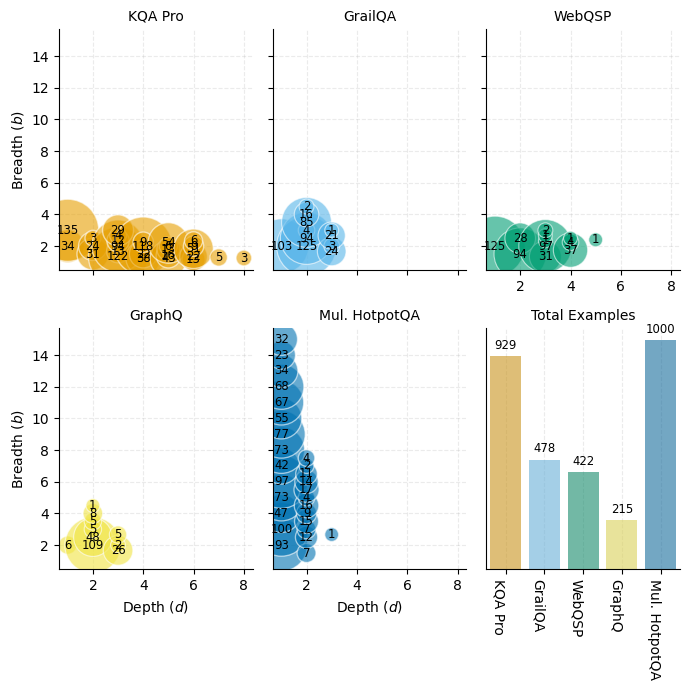

In [13]:
colors = [
    "#999999",
    "#E69F00",
    "#56B4E9",
    "#009E73",
    "#F0E442",
    "#0072B2",
    "#D55E00",
    "#CC79A7",
]

dataset_rename_map = {
    "grailqa": "GrailQA",
    "webqsp": "WebQSP",
    "graphq": "GraphQ",
    "kqa_pro": "KQA Pro",
    "multiobj_hotpotqa": "Mul. HotpotQA",
}
dataset_order = [
    "KQA Pro",
    "GrailQA",
    "WebQSP",
    "GraphQ",
    "Mul. HotpotQA",
]
palette = dict(zip(dataset_order, colors[1 : len(dataset_order) + 1]))

feature_distribution_df = pd.concat(
    [
        atomic_features[["id", "dataset", "critical_path_len", "avg_parallelism"]],
        kqa_features[["id", "dataset", "critical_path_len", "avg_parallelism"]],
        hotpot_features[["id", "dataset", "critical_path_len", "avg_parallelism"]],
    ],
    ignore_index=True,
)

df_counts = (
    feature_distribution_df.groupby(
        ["critical_path_len", "avg_parallelism", "dataset"]
    )
    .size()
    .reset_index(name="count")
    .copy()
)
df_counts["dataset"] = df_counts["dataset"].map(dataset_rename_map)
df_counts["dataset"] = pd.Categorical(
    df_counts["dataset"],
    categories=dataset_order,
    ordered=True,
)
df_counts = df_counts.sort_values(["dataset", "critical_path_len", "avg_parallelism"])

plot_df = feature_distribution_df.copy()
plot_df["dataset"] = plot_df["dataset"].map(dataset_rename_map)
plot_df["dataset"] = pd.Categorical(
    plot_df["dataset"],
    categories=dataset_order,
    ordered=True,
)
total_counts = (
    plot_df["dataset"].value_counts().reindex(dataset_order).fillna(0).astype(int)
)
total_counts_df = pd.DataFrame(
    {
        "dataset": dataset_order,
        "count": total_counts.values,
    }
)

g = sns.relplot(
    data=df_counts,
    x="critical_path_len",
    y="avg_parallelism",
    size="count",
    hue="dataset",
    col="dataset",
    col_wrap=3,
    kind="scatter",
    palette=palette,
    sizes=(100, 2000),
    alpha=0.6,
    height=5,
    aspect=0.45,
    legend=False,
)

g.set_axis_labels("Depth ($d$)", "Breadth ($b$)")
g.figure.set_size_inches(7, 7)
g.set_titles("{col_name}")

for i, ax in enumerate(g.axes.flat):
    ax.set_axisbelow(True)
    ax.grid(True, linestyle="--", alpha=0.25)
    if i < 3:
        ax.set_xlabel("")

    dataset_name = ax.get_title().strip()
    if not dataset_name:
        continue

    subset = df_counts[df_counts["dataset"] == dataset_name]
    for _, row in subset.iterrows():
        ax.text(
            row["critical_path_len"],
            row["avg_parallelism"],
            str(row["count"]),
            horizontalalignment="center",
            verticalalignment="center",
            size="small",
            color="black",
            weight="regular",
        )

ax_total = g.figure.add_subplot(2, 3, 6)
sns.barplot(
    data=total_counts_df,
    x="dataset",
    y="count",
    hue="dataset",
    palette=palette,
    legend=False,
    ax=ax_total,
    alpha=0.6,
)

ref_title_size = g.axes.flat[0].title.get_size()
ax_total.set_title("Total Examples", fontsize=ref_title_size)
ax_total.set_xlabel("")
ax_total.set_ylabel("")
ax_total.set_xticks(range(len(dataset_order)))
ax_total.set_xticklabels(dataset_order, rotation=-90, ha="right")
ax_total.set_yticks([])
ax_total.grid(True, axis="x", linestyle="--", alpha=0.25)
ax_total.set_axisbelow(True)

for container in ax_total.containers:
    ax_total.bar_label(container, padding=3, fontsize="small")

sns.despine(ax=ax_total)
plt.tight_layout()
plt.savefig(output_dir / "figure3_task_space_distribution.pdf", bbox_inches="tight")
plt.show()

In [3]:
summary

,Dataset,Model,Depth ($\beta_d$),Breadth ($\beta_b$),Is SH? ($\beta_\text{SH}$),$\beta_{d:\text{SH}}$,$\beta_{b:\text{SH}}$
0,KQA Pro,GPT-4.1-mini,-0.646**,-0.423**,+0.081,-0.238**,-0.283**
1,KQA Pro,GPT-5-mini,-0.496**,-0.464*,+0.132,+0.047,+0.091
2,KQA Pro,Qwen3-235B-A22B,-0.685**,-0.426**,+0.178*,+0.011,+0.301**
3,KQA Pro,Gemini-3-Flash,-0.396*,-0.465*,-0.413**,-0.111,+0.067
4,Atomic KBQA,GPT-4.1-mini,-0.247**,-0.159*,-0.017,-0.075,-0.076
5,Atomic KBQA,GPT-5-mini,-0.261**,-0.226**,-0.084*,+0.023,+0.017
6,Atomic KBQA,Qwen3-235B-A22B,-0.243**,-0.314**,+0.019,-0.012,+0.036
7,Atomic KBQA,Gemini-3-Flash,-0.261**,-0.139,-0.589**,-0.005,-0.196**
8,Mul. HotpotQA,GPT-4.1-mini,-0.256**,-0.576**,+0.152**,-0.002,-0.051
9,Mul. HotpotQA,GPT-5-mini,-0.275**,-0.470**,-0.057,+0.034,+0.033


In [7]:
question_counts = pd.DataFrame(
    {
        "Dataset family": ["KQA Pro", "Atomic KBQA", "Mul. HotpotQA"],
        "Questions": [
            kqa_frame["question_id"].nunique(),
            atomic_frame["question_id"].nunique(),
            hotpot_frame["question_id"].nunique(),
        ],
    }
)
question_counts

,Dataset family,Questions
0,KQA Pro,929
1,Atomic KBQA,1115
2,Mul. HotpotQA,1000


In [4]:
detailed_display = detailed.copy()
detailed_display["dataset"] = pd.Categorical(
    detailed_display["dataset"],
    categories=DATASET_ORDER,
    ordered=True,
)
detailed_display["model"] = pd.Categorical(
    detailed_display["model"],
    categories=MODEL_ORDER,
    ordered=True,
)
detailed_display["term"] = pd.Categorical(
    detailed_display["term"],
    categories=TERM_ORDER,
    ordered=True,
)

detailed_display[
    ["dataset", "model", "term", "term_label", "coef", "std_err", "pvalue", "n_questions"]
].sort_values(["dataset", "model", "term"]).reset_index(drop=True)

,dataset,model,term,term_label,coef,std_err,pvalue,n_questions
0,KQA Pro,GPT-4.1-mini,critical_path_len,Depth ($\beta_d$),-0.645942,0.127638,4.176251e-07,929
1,KQA Pro,GPT-4.1-mini,avg_parallelism,Breadth ($\beta_b$),-0.423178,0.135987,1.858811e-03,929
2,KQA Pro,GPT-4.1-mini,is_sh,Is SH? ($\beta_\text{SH}$),0.080588,0.069336,2.451223e-01,929
3,KQA Pro,GPT-4.1-mini,critical_path_len:is_sh,$\beta_{d:\text{SH}}$,-0.238225,0.084349,4.738818e-03,929
4,KQA Pro,GPT-4.1-mini,avg_parallelism:is_sh,$\beta_{b:\text{SH}}$,-0.283403,0.091362,1.922359e-03,929
5,KQA Pro,GPT-5-mini,critical_path_len,Depth ($\beta_d$),-0.495960,0.167040,2.986581e-03,929
6,KQA Pro,GPT-5-mini,avg_parallelism,Breadth ($\beta_b$),-0.463709,0.188632,1.396056e-02,929
7,KQA Pro,GPT-5-mini,is_sh,Is SH? ($\beta_\text{SH}$),0.131977,0.078318,9.195967e-02,929
8,KQA Pro,GPT-5-mini,critical_path_len:is_sh,$\beta_{d:\text{SH}}$,0.046915,0.085756,5.843271e-01,929
9,KQA Pro,GPT-5-mini,avg_parallelism:is_sh,$\beta_{b:\text{SH}}$,0.091330,0.093155,3.268866e-01,929


## Interpretation note

If the notebook output differs from a manuscript draft, check that the draft used the same released result bundle. This notebook recomputes the regressions from the current workspace files instead of relying on stale stored notebook outputs.